# The Closing Window — data exploration

Shape-first look at the designer data. Loads the full Phase 2
collection if it exists, otherwise the pilot. Every cell is
independent enough to tweak and re-run.

Run in VS Code (interactive cells) or:
  uv run jupytext --to ipynb notebooks/explore.py && uv run jupyter lab notebooks/explore.ipynb

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ROOT = Path(__file__).resolve().parents[1] if "__file__" in dir() else Path.cwd().parents[0]
DATA = ROOT / "data"

full = DATA / "full" / "designers.parquet"
pilot = DATA / "pilot" / "designers.parquet"
df = pd.read_parquet(full if full.exists() else pilot)
anchors = pd.read_parquet(DATA / "pilot" / "anchors.parquet")

# apply targeted cohort-date corrections (audit_cohorts.py) if present
corr = DATA / "full" / "cohort_corrections.parquet"
if corr.exists() and "designer_id" in df:
    fix = pd.read_parquet(corr)
    fix = dict(zip(fix.loc[fix["changed"], "designer_id"],
                   fix.loc[fix["changed"], "new_cohort"]))
    df["cohort_year"] = [fix.get(i, y) for i, y in
                         zip(df["designer_id"], df["cohort_year"])]
    print(f"applied {len(fix)} cohort corrections")

print(f"loaded {'FULL' if full.exists() else 'PILOT'}: {len(df)} designers, "
      f"{len(anchors)} anchors")
df.head(3)

## Setup: eras, weights, helper stats

In [ ]:
ERA_BINS = [2006, 2012, 2019, 2025]
ERA_LABELS = ["2007-12 (blog)", "2013-19 (early IG)", "2020-24 (algorithm)"]
df["era"] = pd.cut(df["cohort_year"], ERA_BINS, labels=ERA_LABELS)

# institutional-route flag (becca's ruling, 2026-08-07): a pre-2007
# start is NOT evidence of the print route — many bloggers predate
# Ravelry. Institutional requires positive evidence: majority of the
# catalog in print sources. Pre-2007 + low print share = early-web
# self-publisher, i.e. the blog cohort's vanguard, kept in their
# timing-based era.
df["pre_ravelry_pub"] = pd.to_numeric(
    df["first_pub_anywhere"].str[:4], errors="coerce") < 2007
df["institutional"] = df["print_source_share"] > 0.5

# Four-cohort scheme: the print cohort is defined by ROUTE, not year —
# their cohort_year is just the Ravelry import date, so without this
# they'd be miscounted as blog-era. CAVEATS for the print cohort: only
# imported catalogs appear (someone had to care enough to catalog them),
# and their fan counts are the MODERN echo of a print-era career, not
# their own era's audience. Useful precisely as that: what does
# institutional-era reputation convert to in the attention economy?
df["cohort4"] = pd.Categorical(
    np.where(df["institutional"], "print/institutional",
             df["era"].astype(str)),
    categories=["print/institutional"] + ERA_LABELS, ordered=True)
df.groupby("cohort4", observed=True)["fan_count"].describe()

df["crochet_share"] = df["n_crochet"] / (df["n_crochet"] + df["n_knitting"])
df["fans_per_pattern"] = df["fan_count"] / df["n_patterns"]


MILESTONES = [
    (2007, "Ravelry launches"),
    (2010, "Instagram debuts"),
    (2013, "Google Reader dies"),
    (2016, "IG feed goes algorithmic"),
    (2018, "TikTok arrives (US)"),
    (2020, "pandemic + NuRav fracture"),
]


def add_milestones(ax, labels: bool = True) -> None:
    """Dashed era markers for any chart with cohort years on the x-axis."""
    ymax = ax.get_ylim()[1]
    for year, label in MILESTONES:
        ax.axvline(year, ls="--", lw=0.8, color="grey", alpha=0.6)
        if labels:
            ax.text(year, ymax * 0.98, f" {label}", rotation=90,
                    va="top", ha="left", fontsize=7, color="grey")


def gini(x) -> float | None:
    x = np.sort(np.asarray(x, dtype=float))
    x = x[~np.isnan(x)]
    n = len(x)
    if n == 0 or x.sum() == 0:
        return None
    return float((2 * np.arange(1, n + 1) - n - 1).dot(x) / (n * x.sum()))


df.groupby("era", observed=True)["fan_count"].describe()

## 0b. Platform output per year (from the ID census)
Pattern IDs are sequential, so each year's ID-range width estimates
patterns created that year (including later-deleted ones). NOTE: our
designer sample CANNOT measure cohort sizes — the 50/year quota
flattens them by design. This census is the platform-level
denominator; a designer-cohort-size estimator (share of each year's
patterns that are first-year output) is a planned follow-up pass.

In [ ]:
import json
id_map = json.loads((DATA / "manifests" / "id_year_map.json").read_text())
pts = sorted(map(tuple, id_map))
year_width: dict[int, int] = {}
for (id0, y0), (id1, y1) in zip(pts, pts[1:]):
    gap = id1 - id0
    if gap > 250_000:  # the 2023 ID re-basing hole — no patterns there
        continue
    year_width[y0] = year_width.get(y0, 0) + gap

census = pd.Series(year_width).sort_index()
fig, ax = plt.subplots(figsize=(12, 4))
census.plot(kind="bar", ax=ax)
ax.set_ylabel("new pattern IDs issued")
ax.set_title("Patterns added to Ravelry per year (ID-census estimate)")
plt.tight_layout()
census

## 1. The headline shape: fan distributions by cohort year
Log scale — the compression of the middle should be visible here
before any statistics. (This is the violin the research plan wanted.)

In [ ]:
plot_df = df.dropna(subset=["cohort_year", "fan_count"]).copy()
plot_df["log_fans"] = np.log10(plot_df["fan_count"] + 1)

fig, ax = plt.subplots(figsize=(14, 6))
sns.stripplot(data=plot_df, x="cohort_year", y="log_fans",
              alpha=0.5, size=4, ax=ax)
sns.boxplot(data=plot_df, x="cohort_year", y="log_fans",
            showfliers=False, boxprops=dict(alpha=0.3), ax=ax)
ax.set_ylabel("log10(fans + 1)")
ax.set_title("Fan distributions by first-publication year")
plt.xticks(rotation=45)
plt.tight_layout()

## 2. Middle-band share — "the middle is falling out"
Share of each cohort with 500–5,000 fans (the livable middle).
Also floor (≥100 fans) and breakout (≥10k) rates.

In [ ]:
by_year = df.dropna(subset=["cohort_year"]).groupby("cohort_year")["fan_count"]
summary = pd.DataFrame({
    "n": by_year.size(),
    "median": by_year.median(),
    "middle_band": by_year.apply(lambda f: ((f >= 500) & (f <= 5000)).mean()),
    "floor_100": by_year.apply(lambda f: (f >= 100).mean()),
    "breakout_10k": by_year.apply(lambda f: (f >= 10_000).mean()),
    "gini": by_year.apply(gini),
})
summary

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
summary["middle_band"].plot(marker="o", ax=ax, label="middle band (500-5k fans)")
summary["floor_100"].plot(marker="s", ax=ax, label="reached 100 fans")
ax.set_ylabel("share of cohort")
ax.set_title("The middle band by cohort year")
ax.legend()
add_milestones(ax)
plt.tight_layout()

## 2c. Golden ages: when was the window open, and for how long?
"Open" = a cohort year whose entrants had a decent shot at finding
any audience: share reaching 100 fans >= 55%. Shaded spans are
consecutive open years — their widths measure each golden age.
(Print-era window predates the data; institutional entrants excluded.)

In [ ]:
sp = df[(df["print_source_share"] <= 0.5)].dropna(
    subset=["cohort_year", "fan_count"])
fl = sp.groupby("cohort_year")["fan_count"].apply(
    lambda f: (f >= 100).mean())
fl = fl[(fl.index >= 2007) & (fl.index <= 2023)]

OPEN = 0.55
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(fl.index, fl.values, marker="o", color="black", lw=1.5)
ax.axhline(OPEN, ls=":", color="grey", lw=1)
# shade consecutive open runs and label their widths
run_start = None
spans = []
for year in list(fl.index) + [None]:
    is_open = year is not None and fl[year] >= OPEN
    if is_open and run_start is None:
        run_start = year
    elif not is_open and run_start is not None:
        spans.append((run_start, prev))
        run_start = None
    if year is not None:
        prev = year
for lo, hi in spans:
    ax.axvspan(lo - 0.5, hi + 0.5, alpha=0.15, color="green")
    ax.text((lo + hi) / 2, 0.05, f"{int(hi - lo + 1)} yr window",
            ha="center", fontsize=9, color="darkgreen")
add_milestones(ax)
ax.set_ylabel("share of cohort reaching 100 fans")
ax.set_title("Golden ages: open-window years and their shrinking width")
plt.tight_layout()
print("open spans:", spans)

## 2b. Concentration: who holds the cohort's attention?
The direct picture of "fewer designers, outsized influence."

Left: Lorenz curves — designers ranked poorest to richest along x,
cumulative share of the cohort's total fans along y. The diagonal is
perfect equality; the deeper the bow, the more the cohort's attention
belongs to its top few. This is the same chart used for wealth
inequality, which is the point.

Right: share of each cohort's total fans held by its top 10% and top
1 designer.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for era in ERA_LABELS:
    fans = np.sort(df.loc[df["era"] == era, "fan_count"].dropna().values)
    if len(fans) < 5 or fans.sum() == 0:
        continue
    cum = np.insert(np.cumsum(fans) / fans.sum(), 0, 0)
    x = np.linspace(0, 1, len(cum))
    axes[0].plot(x, cum, marker=".", label=f"{era} (n={len(fans)})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="perfect equality")
axes[0].set_xlabel("share of designers (poorest → richest)")
axes[0].set_ylabel("cumulative share of cohort's fans")
axes[0].set_title("Lorenz curves by cohort")
axes[0].legend()

conc = []
for era in ERA_LABELS:
    fans = df.loc[df["era"] == era, "fan_count"].dropna().sort_values(
        ascending=False)
    if len(fans) < 5 or fans.sum() == 0:
        continue
    n10 = max(1, len(fans) // 10)
    top1 = fans.iloc[0] / fans.sum()
    top10 = fans.head(n10).sum() / fans.sum()
    conc.append({"era": era,
                 "top 1 designer": top1,
                 "rest of top 10%": top10 - top1,
                 "bottom 90% of designers": 1 - top10})
conc_df = pd.DataFrame(conc).set_index("era")
conc_df.plot(kind="bar", stacked=True, ax=axes[1], rot=15,
             color=["#8c1d1d", "#d97757", "#c9c4bb"])
axes[1].set_ylabel("share of cohort's total fans")
axes[1].set_title("Who holds the cohort's attention (stacks to 100%)")
axes[1].legend(fontsize=8)
plt.tight_layout()
conc_df.round(3)

## 3. Time-on-platform control: fans per year since first publication
The raw medians conflate cohort with account age; this is the
plan's normalization.

In [ ]:
df["years_active"] = 2026 - df["cohort_year"]
df["fans_per_year"] = df["fan_count"] / df["years_active"].clip(lower=1)
df.groupby("cohort4", observed=True)[["fans_per_year", "fans_per_pattern",
                                      "fan_count"]].median()

## 3b. Fans per pattern by cohort year
The "audience earned per unit of output" measure — the ceiling story.
Median (solid) is the honest central line for heavy-tailed data; the
mean (dashed) is shown for contrast — where they diverge, an outlier
is doing the talking. Shaded band = 25th–75th percentile.

In [ ]:
fpp = df.dropna(subset=["cohort_year", "fans_per_pattern"])
by_year_fpp = fpp.groupby("cohort_year")["fans_per_pattern"]

fig, ax = plt.subplots(figsize=(13, 5))
med = by_year_fpp.median()
ns = by_year_fpp.size()
ax.plot(med.index, med.values, lw=1.5, label="median")
# marker area tracks sample size: big dots are trustworthy, small
# dots are gossip
ax.scatter(med.index, med.values, s=ns.clip(upper=300), zorder=3)
ax.plot(by_year_fpp.mean().index, by_year_fpp.mean().values,
        linestyle="--", marker=".", alpha=0.6, label="mean")
ax.fill_between(med.index, by_year_fpp.quantile(0.25).values,
                by_year_fpp.quantile(0.75).values, alpha=0.15,
                label="25th–75th pct")
ax.set_xlabel("cohort year (first publication)")
ax.set_ylabel("fans per pattern published")
ax.set_title("Audience earned per pattern, by cohort")
ax.legend()
add_milestones(ax)
plt.tight_layout()
by_year_fpp.agg(["count", "median", "mean"]).round(2)

## 4. H7 — the crochet lag
Same shapes, split by craft. Crochet-majority designers should show
a later, still-open window.

In [ ]:
df["craft"] = np.where(df["crochet_share"] > 0.5, "crochet", "knitting")
df.groupby(["era", "craft"], observed=True).agg(
    n=("fan_count", "size"),
    median_fans=("fan_count", "median"),
    median_fpy=("fans_per_year", "median"),
    gini=("fan_count", gini),
)

## 4b. Top designers per cohort year
Who from each entry class holds the most attention TODAY. (Fans are
lifetime totals with no timestamps — this is the class reunion, not
the yearbook. Historical accumulation lives in the Wayback panels.)

In [ ]:
top = (df.dropna(subset=["cohort_year", "fan_count"])
         .sort_values("fan_count", ascending=False)
         .groupby("cohort_year")
         .head(3)
         .sort_values(["cohort_year", "fan_count"],
                      ascending=[True, False]))
top[["cohort_year", "designer_name", "fan_count", "n_patterns",
     "fans_per_pattern", "instagram"]].reset_index(drop=True)

## 4c. Cohort winners: career spans
Each cohort year's top designer as a horizontal bar from first to
last publication, labeled with current fans. Dashed lines mark the
hypothesized inflection points (Google Reader death 2013, Instagram
algorithmic feed 2016). Fans have no timestamps, so this shows how
long each winner KEPT PUBLISHING, not when the fans arrived — that
needs the Wayback panels / per-pattern hit curves.

In [ ]:
champs = (df.dropna(subset=["cohort_year", "fan_count"])
            .sort_values("fan_count", ascending=False)
            .groupby("cohort_year").head(1)
            .sort_values("cohort_year"))
champs["first_y"] = pd.to_numeric(champs["first_pub_anywhere"].str[:4],
                                  errors="coerce")
champs["last_y"] = pd.to_numeric(champs["last_pattern_published"].str[:4],
                                 errors="coerce")

fig, ax = plt.subplots(figsize=(12, 0.45 * len(champs) + 2))
for i, (_, c) in enumerate(champs.iterrows()):
    if pd.isna(c["first_y"]) or pd.isna(c["last_y"]):
        continue
    ax.barh(i, max(c["last_y"] - c["first_y"], 0.3), left=c["first_y"],
            height=0.6, alpha=0.7)
    ax.text(c["last_y"] + 0.2, i,
            f"{c['designer_name']}  ({int(c['fan_count']):,} fans)",
            va="center", fontsize=8)
for x, label in [(2013, "Reader dies"), (2016, "IG algorithm")]:
    ax.axvline(x, ls="--", lw=1, color="grey")
    ax.text(x, len(champs) + 0.3, label, fontsize=8, ha="center",
            color="grey")
ax.set_yticks(range(len(champs)))
ax.set_yticklabels([f"class of {int(y)}" for y in champs["cohort_year"]])
ax.set_xlabel("publishing career span (first -> last pattern)")
ax.set_title("Each cohort's current champion: how long they kept publishing")
plt.tight_layout()

## 4d. Release timelines: every pattern, every canon designer
One row per designer (ordered by entry year), one dot per pattern at
its publication date. Dot size = favorites (the hits surface from the
stream). The cadence differences read as dot density; the era
milestones cross all rows.

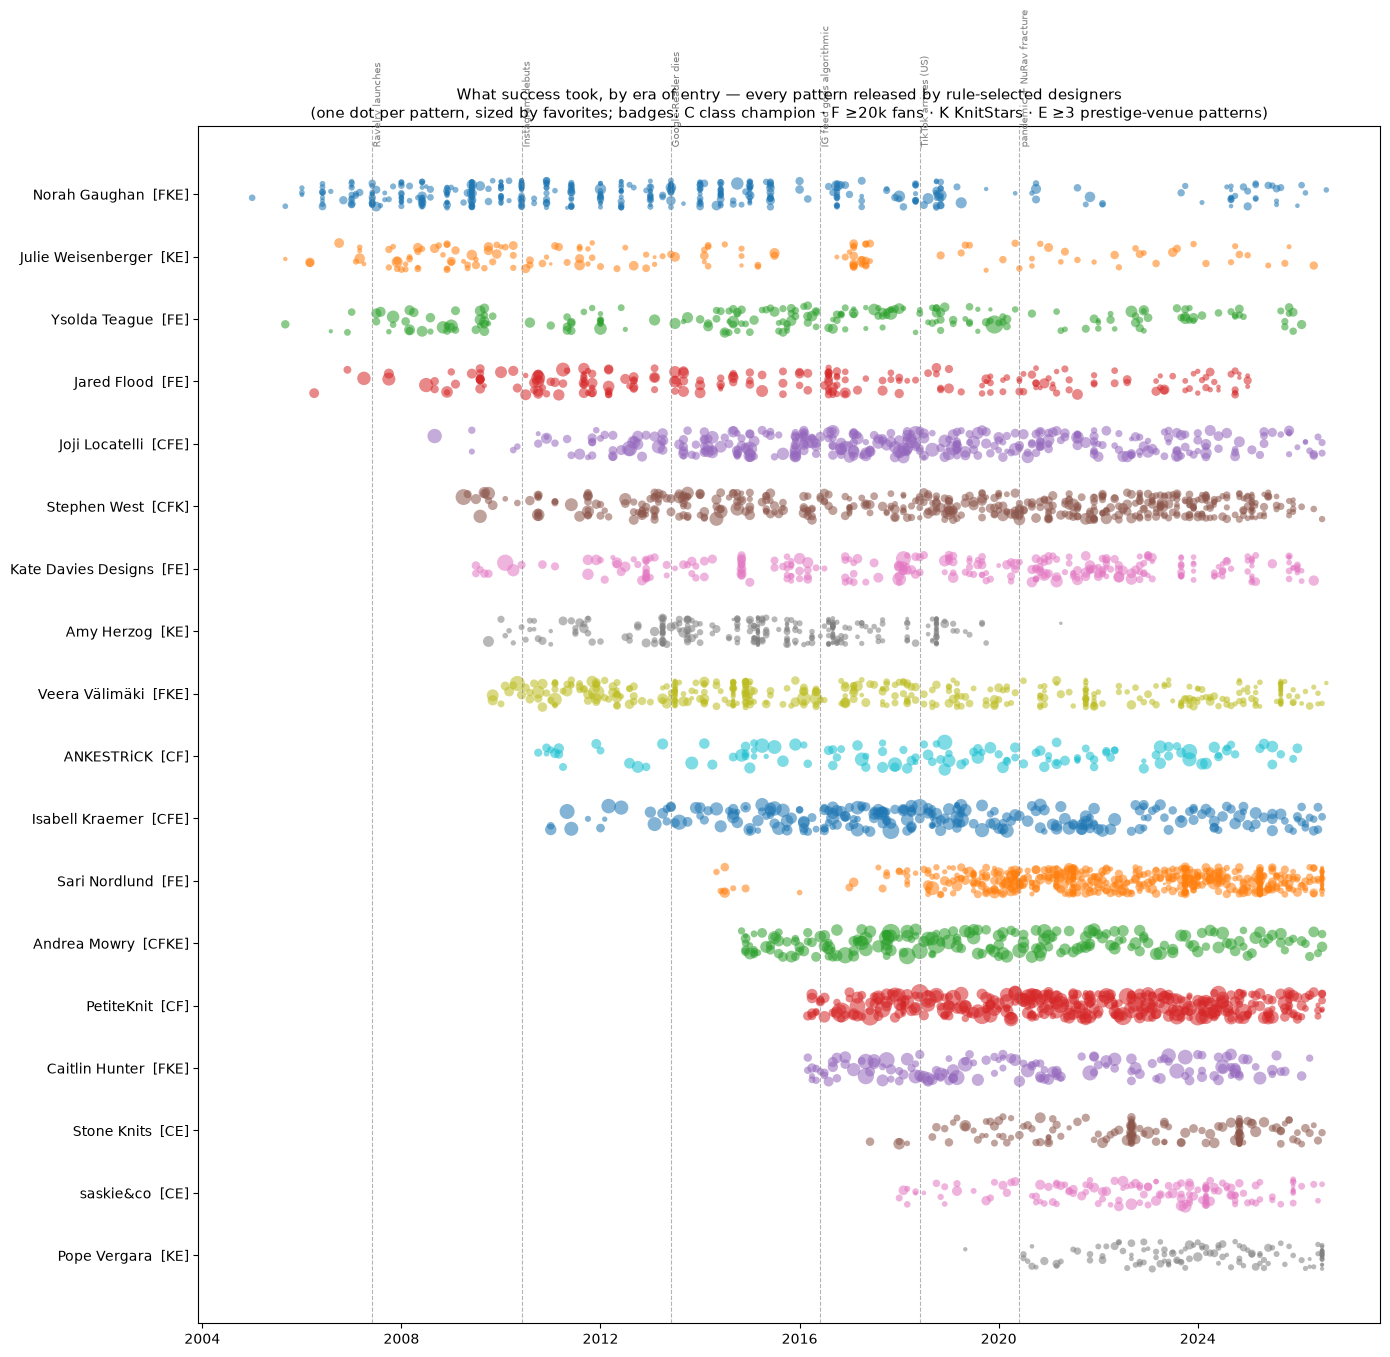

In [429]:
pl = pd.read_parquet(DATA / "full" / "pattern_level.parquet")
pl["date"] = pd.to_datetime(pl["published"], format="%Y/%m/%d",
                            errors="coerce")
# EZ's classics carry no published date on Ravelry; date them from their
# documented print history (BSJ: 1968 newsletter; Tomten/Seamless
# Hybrid: Knitting Without Tears 1971; February/September sweaters:
# Knitter's Almanac 1974). Curated overrides, flagged in any caption.
EZ_DATES = {"Baby Surprise Jacket": "1968-06-01",
            "Tomten Jacket": "1971-06-01",
            "Seamless Hybrid": "1971-06-01",
            "Baby Sweater on Two Needles (February)": "1974-06-01",
            "Nether Garments - Adult (September)": "1974-06-01"}
ez_mask = pl["designer_name"] == "Elizabeth Zimmermann"
pl.loc[ez_mask, "date"] = pl.loc[ez_mask].apply(
    lambda r: pd.Timestamp(EZ_DATES[r["name"]])
    if r["name"] in EZ_DATES else r["date"], axis=1)
pl = pl.dropna(subset=["date"])

# rows sorted by entrance: each designer's first published pattern
# (institutional back-catalogs float naturally to the top).
# Pearl-McPhee's near-empty row is the essayist model; Herzog's row
# stops in 2021 (the exit, visible); Attic24 is blog-era crochet.
# MECHANICAL CAST (becca's rule, 2026-08-09): knitters holding >=2 of
# four currencies — C: class champion in the random sample (self-pub
# route, corrections applied); F: >=20k Ravelry fans; K: KnitStars
# roster; E: >=3 prestige-periodical patterns. Entities excluded per
# collection protocol. No editorial picks; case studies live in
# companion exhibits. Row labels carry the badges.
import yaml as _yaml
_df = pd.read_parquet(DATA / "full" / "designers.parquet")
_corr = pd.read_parquet(DATA / "full" / "cohort_corrections.parquet")
_fix = dict(zip(_corr.loc[_corr["changed"], "designer_id"],
                _corr.loc[_corr["changed"], "new_cohort"]))
_df["cohort_year"] = [_fix.get(i, y) for i, y in
                      zip(_df["designer_id"], _df["cohort_year"])]
_a = pd.read_parquet(DATA / "pilot" / "anchors.parquet")
_k = pd.concat([_df, _a.assign(cohort_year=pd.NA)]) \
       .drop_duplicates("designer_id")
_k = _k[_k["n_knitting"] >= _k["n_crochet"]]
_sp = _k[(_k["print_source_share"] <= 0.5)
         & _k["cohort_year"].between(2007, 2024)]
C = set(_sp.sort_values("fan_count", ascending=False)
           .groupby("cohort_year").head(1)["designer_name"])
F = set(_k[_k["fan_count"] >= 20000]["designer_name"])
_ks = _yaml.safe_load((DATA / "knitstars_roster.yaml").read_text())
_stars = {s for sea in _ks["seasons"].values() for s in sea["stars"]}
K = {n for n in _k["designer_name"]
     if any(str(n).split(" (")[0].lower() in s.lower()
            or s.lower() in str(n).lower() for s in _stars)}
_ed = pd.read_csv(DATA / "full" / "editorial_prestige.csv")
E = set(_ed[_ed["prestige_patterns"] >= 3]["designer"]) \
    & set(_k["designer_name"])
ENTITIES = {"Purl Soho"}
badge = {n: "".join(b for b, s in zip("CFKE", (C, F, K, E)) if n in s)
         for n in (C | F | K | E) - ENTITIES}
CANON = [n for n, b in badge.items() if len(b) >= 2]
sub = pl[pl["designer_name"].isin(CANON)].copy()
CANON = [n for n in CANON if n in set(sub["designer_name"])]
first_date = sub.groupby("designer_name")["date"].min()
CANON = sorted(CANON, key=lambda n: first_date.get(n, pd.Timestamp.max))
ROW_LABELS = [f"{n}  [{badge[n]}]" for n in CANON]
sub = sub[sub["date"] >= "2005-01-01"]

fig, ax = plt.subplots(figsize=(14, 0.65 * len(CANON) + 2))
rng_j = np.random.default_rng(2)
for i, name in enumerate(CANON):
    g = sub[sub["designer_name"] == name]
    jitter = rng_j.uniform(-0.22, 0.22, len(g))
    sizes = 4 + np.sqrt(g["favorites"].fillna(0)) * 0.55
    ax.scatter(g["date"], np.full(len(g), i) + jitter, s=sizes,
               alpha=0.55, edgecolors="none")
ax.set_yticks(range(len(CANON)))
ax.set_yticklabels(ROW_LABELS)
ax.invert_yaxis()
for year, label in MILESTONES:
    x = pd.Timestamp(f"{year}-06-01")
    ax.axvline(x, ls="--", lw=0.8, color="grey", alpha=0.6)
    ax.text(x, -0.7, f" {label}", rotation=90, va="bottom", ha="left",
            fontsize=7, color="grey")
ax.set_title(
    "What success took, by era of entry — every pattern released by "
    "rule-selected designers\n(one dot per pattern, sized by favorites; "
    "badges: C class champion · F ≥20k fans · K KnitStars · "
    "E ≥3 prestige-venue patterns)", fontsize=11)
plt.tight_layout()
fig.savefig(ROOT / "reports" / "cadence_timeline.png", dpi=150,
            bbox_inches="tight")

## 5. The institutional route — print share by cohort

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
df.dropna(subset=["cohort_year"]).groupby("cohort_year")[
    "print_source_share"].mean().plot(marker="o", ax=ax)
ax.set_title("Mean print-source share by cohort (the institutional door closing)")
plt.tight_layout()

## 6. Persistence — last publication recency by cohort
The viability proxy: still publishing?

In [ ]:
df["last_pub_year"] = pd.to_numeric(df["last_pattern_published"].str[:4],
                                    errors="coerce")
df["active_recent"] = df["last_pub_year"] >= 2024
df.groupby("era", observed=True)["active_recent"].mean()

## 7. Anchors vs. the field
Where do the named designers sit against the sampled distribution?

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.stripplot(data=plot_df, x="era", y="log_fans", alpha=0.3, size=3,
              color="grey", ax=ax)
for _, a in anchors.iterrows():
    if pd.notna(a.get("fan_count")):
        ax.axhline(np.log10(a["fan_count"] + 1), lw=0.5, alpha=0.4, color="crimson")
ax.set_title("Sampled designers (grey) vs anchor fan levels (red lines)")
plt.tight_layout()